/tmp/ipykernel_10551/1161890704.py:18: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img.ravel(), 256, [0, 256], color='black')


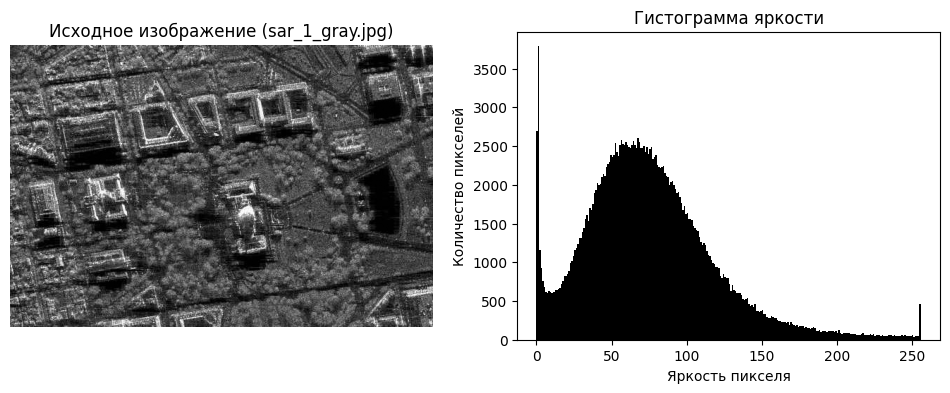

In [106]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim

img = cv2.imread('sar_1_gray.jpg', cv2.IMREAD_GRAYSCALE)

#гистограмма
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Исходное изображение (sar_1_gray.jpg)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.hist(img.ravel(), 256, [0, 256], color='black')
plt.title('Гистограмма яркости')
plt.xlabel('Яркость пикселя')
plt.ylabel('Количество пикселей')

plt.show()

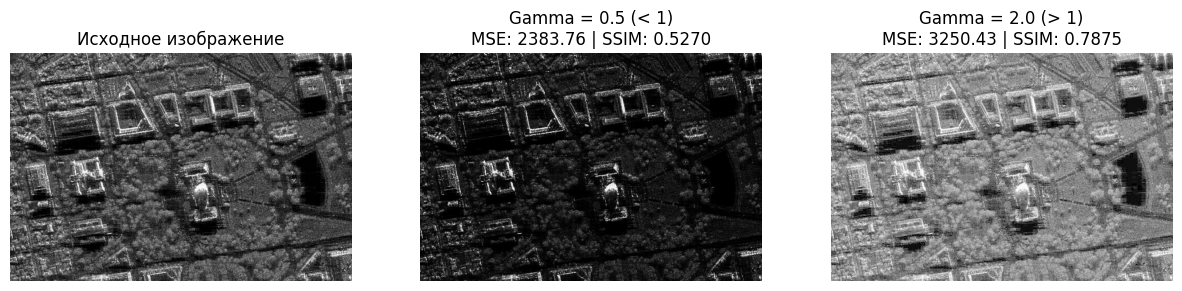

In [107]:
#гамма-коррекция
def gamma_correction(image, gamma):
    inv_gamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** inv_gamma) * 255 for i in range(256)]).astype("uint8")
    return cv2.LUT(image, table)

#MSE
def get_mse(img1, img2):
    return np.mean((img1.astype("float") - img2.astype("float")) ** 2)

img_gamma_low = gamma_correction(img, gamma=0.5)
img_gamma_high = gamma_correction(img, gamma=2.0)

mse_low = get_mse(img, img_gamma_low)
ssim_low = ssim(img, img_gamma_low)

mse_high = get_mse(img, img_gamma_high)
ssim_high = ssim(img, img_gamma_high)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_gamma_low, cmap='gray')
plt.title(f'Gamma = 0.5 (< 1)\nMSE: {mse_low:.2f} | SSIM: {ssim_low:.4f}')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_gamma_high, cmap='gray')
plt.title(f'Gamma = 2.0 (> 1)\nMSE: {mse_high:.2f} | SSIM: {ssim_high:.4f}')
plt.axis('off')

plt.show()

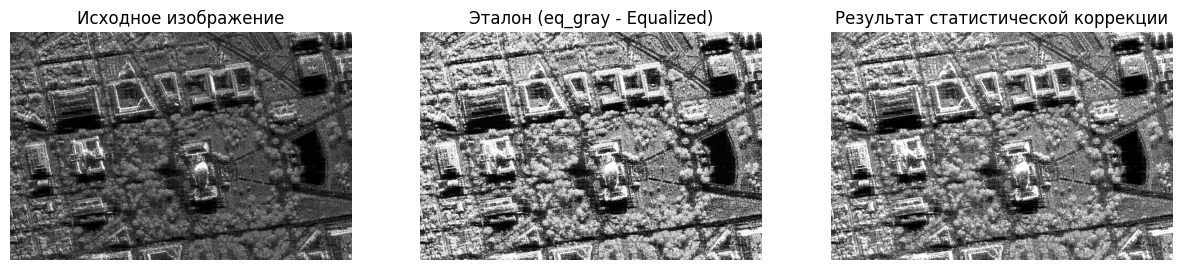

In [108]:
eq_gray = cv2.equalizeHist(img)

def stat_correction_by_target(source, target):
    s_mean, s_std = source.mean(), source.std()
    t_mean, t_std = target.mean(), target.std()

    res = (source.astype(np.float32) - s_mean) * (t_std / s_std) + t_mean
    return np.clip(res, 0, 255).astype(np.uint8)

stat_corrected = stat_correction_by_target(img, eq_gray)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(eq_gray, cmap='gray')
plt.title('Эталон (eq_gray - Equalized)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(stat_corrected, cmap='gray')
plt.title('Результат статистической коррекции')
plt.axis('off')

plt.show()

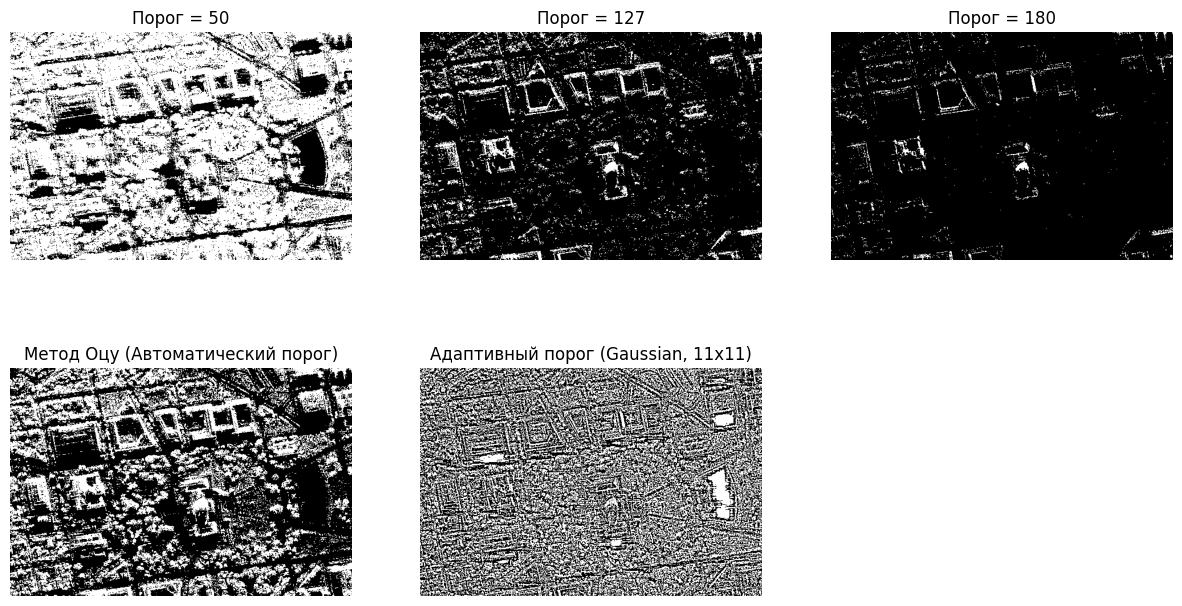

In [109]:
_, thresh_50 = cv2.threshold(img, 50, 255, cv2.THRESH_BINARY)
_, thresh_127 = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
_, thresh_180 = cv2.threshold(img, 180, 255, cv2.THRESH_BINARY)
_, thresh_otsu = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
thresh_adapt = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)

plt.figure(figsize=(15, 8))

plt.subplot(2, 3, 1)
plt.imshow(thresh_50, cmap='gray')
plt.title('Порог = 50')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(thresh_127, cmap='gray')
plt.title('Порог = 127')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(thresh_180, cmap='gray')
plt.title('Порог = 180')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(thresh_otsu, cmap='gray')
plt.title('Метод Оцу (Автоматический порог)')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(thresh_adapt, cmap='gray')
plt.title('Адаптивный порог (Gaussian, 11x11)')
plt.axis('off')

plt.show()